Gewähltes Anwendungsszenario

Road Traffic

## Aufgabe A.

Bestimmen Sie Lage und Streuung aller Merkmale inkl. Zielvariablen. Die Parameter für Lage
und Streuung sind selbst zu wählen. Welche zwei Merkmale sind sich bzgl. Lage und Streuung
am ähnlichsten bzw. am unähnlichsten? Sollte der Datensatz standardisiert werden?
Begründen Sie.

In [51]:
import pandas as pd
import numpy as np

df = pd.read_csv("traffic-prediction-dataset.csv")
df.columns = [c.strip() for c in df.columns]

# Modus berechnen
mode_values = df.mode(numeric_only=True).iloc[0]

stats = pd.DataFrame({
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True),
    "mode": mode_values,
    "q1": df.quantile(0.25, numeric_only=True),
    "q3": df.quantile(0.75, numeric_only=True),
    "std": df.std(numeric_only=True),
    "var": df.var(numeric_only=True),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})

# Zusätzliche Streuungsmaße
stats["range"] = stats["max"] - stats["min"]
stats["iqr"] = stats["q3"] - stats["q1"]

# Reihenfolge der Spalten
stats = stats[
    ["mean", "median", "mode", "q1", "q3", "std", "var", "range", "iqr"]
]

# Ausgabe runden
stats.round(3)

,mean,median,mode,q1,q3,std,var,range,iqr
Cross 1,95.806,88.0,0.0,8.0,169.0,87.587,7671.433,352.5,161.0
Cross 2,45.948,29.0,0.0,2.0,77.0,50.865,2587.253,302.0,75.0
Cross 3,41.510,32.0,0.0,1.0,73.0,41.850,1751.388,218.0,72.0
Cross 4,67.657,45.0,0.0,0.0,124.0,68.536,4697.203,312.0,124.0
Cross 5,36.232,28.0,0.0,1.0,60.0,37.372,1396.700,193.0,59.0
Cross 6,76.215,66.0,0.0,5.0,139.0,68.102,4637.854,253.0,134.0


In [52]:
compare_cols = ["mean", "median", "std", "iqr"]
pairs = []

for i, c1 in enumerate(stats.index):
    for c2 in stats.index[i+1:]:
        d = np.linalg.norm(stats.loc[c1, compare_cols].values - stats.loc[c2, compare_cols].values)
        pairs.append((c1, c2, d))

pair_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "distance"]).sort_values("distance")
pair_df.round(3)

,feature_1,feature_2,distance
5,Cross 2,Cross 3,10.908
10,Cross 3,Cross 5,15.261
7,Cross 2,Cross 5,23.097
13,Cross 4,Cross 6,24.788
4,Cross 1,Cross 6,44.458
6,Cross 2,Cross 4,58.656
9,Cross 3,Cross 4,65.336
2,Cross 1,Cross 4,66.131
8,Cross 2,Cross 6,77.866
12,Cross 4,Cross 5,80.453


In [53]:
most_similar = pair_df.iloc[0]
most_different = pair_df.iloc[-1]

print("Most similar:")
print(most_similar.to_string())
print()
print("Most different:")
print(most_different.to_string())

Most similar:
feature_1      Cross 2
feature_2      Cross 3
distance     10.907581

Most different:
feature_1       Cross 1
feature_2       Cross 5
distance     141.684525


Standardisierung wird empfohlen, da sich die Merkmale in ihrer Lage und Streuung unterscheiden.

Der Modus ist bei vielen Merkmalen gleich, da der häufigste Wert oft 0 ist. Das liegt daran, dass es an jeder Kreuzung Zeitpunkte gibt, zu denen kein Verkehr vorhanden ist. Dadurch ähneln sich die Merkmale hinsichtlich ihres Modus stark.

Am unterschiedlichsten sind dagegen die Mittelwerte der Merkmale. Das zeigt, dass sich das durchschnittliche Verkehrsaufkommen zwischen den einzelnen Kreuzungen deutlich unterscheidet.


## Lageparameter

Text(0, 0.5, 'Werte')

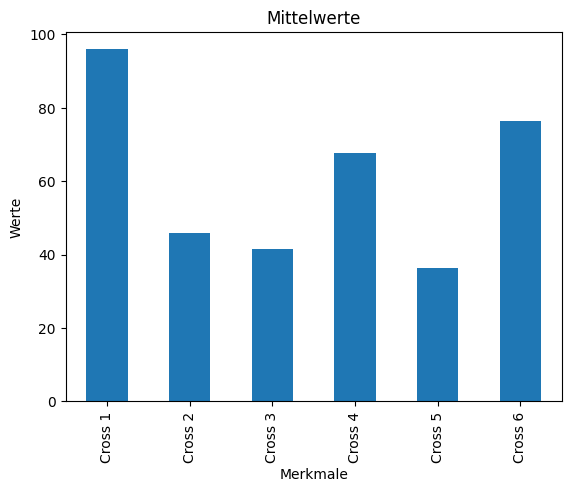

In [54]:
import statistics as st
import matplotlib.pyplot as plt

road_traffic_df = pd.read_csv('traffic-prediction-dataset.csv')
road_traffic_df.columns = ['Cross 1', 'Cross 2','Cross 3','Cross 4','Cross 5','Cross 6']

cols = ['Cross 1', 'Cross 2','Cross 3','Cross 4','Cross 5','Cross 6']
rows_lage = ['Mittelwert', 'Median', 'Modus', 'Quantil25', 'Quantil50', 'Quantil75']
rows_streuung = ['Varianz', 'Standardabweichung', 'Spannweite']

# Erzeugt die leere Struktur automatisch
lage = {r: {c: 'value' for c in cols} for r in rows_lage}

boxplot = {c: 'value' for c in cols}

streuung = {r: {c: 'value' for c in cols} for r in rows_streuung}

# Berechnung von Werten: Mittelwerte, Mediane, Modi, Standardabweichungen, Quantile, Spannweiten, Varianzen
for i in (road_traffic_df):
    col = road_traffic_df.loc[:, i]

    lage['Mittelwert'][i] = col.mean()
    lage['Median'][i] = col.median()
    lage['Modus'][i] = col.mode().iloc[0]
    streuung['Varianz'][i] = np.var(col)
    streuung['Standardabweichung'][i] = st.stdev(col)
    streuung['Spannweite'][i] = max(col) - min(col)
    lage['Quantil25'][i] = np.quantile(col, 0.25)
    lage['Quantil50'][i] = np.quantile(col, 0.50)
    lage['Quantil75'][i] = np.quantile(col, 0.75)
    boxplot[i] = col

# Werte als DataFrames
lage_df = pd.DataFrame(lage)
streuung_df = pd.DataFrame(streuung)
boxplot_df = pd.DataFrame(boxplot)

# Barplot Mittelwerte
lage_df.loc[:, 'Mittelwert'].plot.bar()

plt.title("Mittelwerte")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

<Figure size 10000x20000 with 0 Axes>

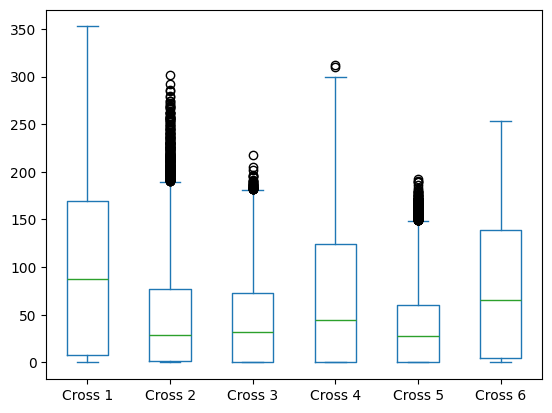

<Figure size 10000x20000 with 0 Axes>

In [55]:
# Boxplot der Originalwerte
boxplot_df.plot.box(autorange=True, zorder=2)

plt.figure(figsize=(100,200))
#plt.title("Mittelwerte")
#plt.xlabel("Merkmale")
#plt.ylabel("Werte")

In [56]:
# Berechnung kleinster Abweichungen der Lagewerte
result = []
for index in lage_df.columns :
    values = lage_df[index].values
    variablenames = lage_df.index.tolist()
    diffrences_matrix = np.abs(values[:,None] - values)
    np.fill_diagonal(diffrences_matrix,np.nan)
    min_diff = np.nanmin(diffrences_matrix)
    idx = np.where(diffrences_matrix == min_diff)
    var1 = variablenames[idx[0][0]]
    var2 = variablenames[idx[1][0]]
    
    result.append({
        "Kennzahl": index,
        "Kleinste Differenz": min_diff,
        "Variablenpaar": f"{var1} – {var2}"
    })
    result_df = pd.DataFrame(result)
    
print(result_df)

     Kennzahl  Kleinste Differenz      Variablenpaar
0  Mittelwert            4.438089  Cross 2 – Cross 3
1      Median            1.000000  Cross 2 – Cross 5
2       Modus            0.000000  Cross 1 – Cross 2
3   Quantil25            0.000000  Cross 3 – Cross 5
4   Quantil50            1.000000  Cross 2 – Cross 5
5   Quantil75            4.000000  Cross 2 – Cross 3


## Streuungsparameter

Text(0, 0.5, 'Werte')

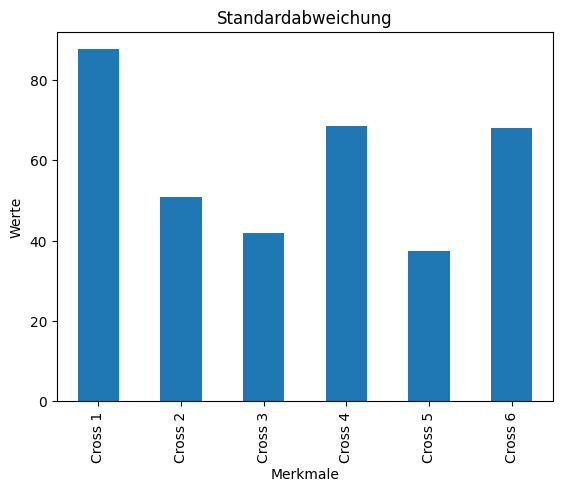

In [57]:
# Barplot Standardabweichungen
streuung_df.loc[:, 'Standardabweichung'].plot.bar()

plt.title("Standardabweichung")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

Text(0, 0.5, 'Werte')

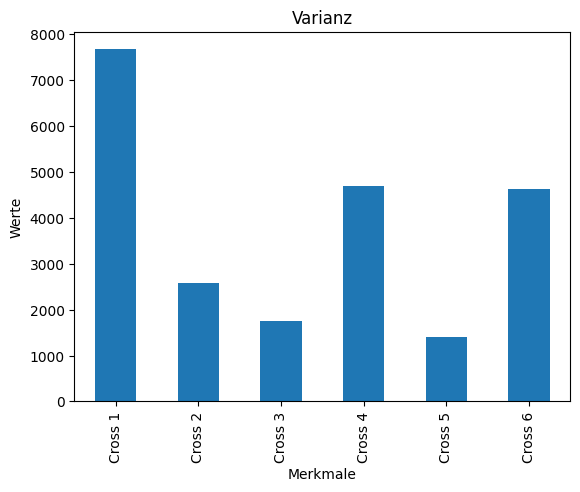

In [58]:
#Barplot Varianzen
streuung_df.loc[:, 'Varianz'].plot.bar()

plt.title("Varianz")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

Text(0, 0.5, 'Werte')

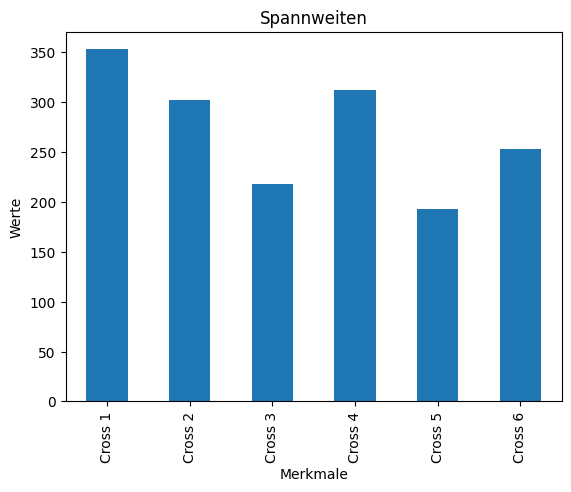

In [59]:
# Barplot Spannweiten
streuung_df.loc[:, 'Spannweite'].plot.bar()

plt.title("Spannweiten")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

In [60]:
# Berechnung kleinster Abweichungen der Streuungswerte
result = []
for index in streuung_df.columns :
    values = streuung_df[index].values
    variablenames = streuung_df.index.tolist()
    diffrences_matrix = np.abs(values[:,None] - values)
    np.fill_diagonal(diffrences_matrix,np.nan)
    min_diff = np.nanmin(diffrences_matrix)
    idx = np.where(diffrences_matrix == min_diff)
    var1 = variablenames[idx[0][0]]
    var2 = variablenames[idx[1][0]]
    result.append({
        "Kennzahl": index,
        "Kleinste Differenz": min_diff,
        "Variablenpaar": f"{var1} – {var2}"
    })
    result_df = pd.DataFrame(result)
print(result_df)

             Kennzahl  Kleinste Differenz      Variablenpaar
0             Varianz           59.344752  Cross 4 – Cross 6
1  Standardabweichung            0.434348  Cross 4 – Cross 6
2          Spannweite           10.000000  Cross 2 – Cross 4


## Aufgabe B.

Visualisieren Sie die Merkmale nach einer Standardisierung (Die Methode ist selbst zu wählen)
in einem Boxplot. Vergleichen Sie die standardisierten Daten mit den originalen Daten. Was
fällt Ihnen auf?

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("traffic-prediction-dataset.csv")
df.columns = [c.strip() for c in df.columns]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print(df.describe().round(3))
print()
print(df_scaled.describe().round(3))

         Cross 1    Cross 2   Cross 3    Cross 4    Cross 5    Cross 6
count  16128.000  16128.000  16128.00  16128.000  16128.000  16128.000
mean      95.806     45.948     41.51     67.657     36.232     76.215
std       87.587     50.865     41.85     68.536     37.372     68.102
min        0.000      0.000      0.00      0.000      0.000      0.000
25%        8.000      2.000      1.00      0.000      1.000      5.000
50%       88.000     29.000     32.00     45.000     28.000     66.000
75%      169.000     77.000     73.00    124.000     60.000    139.000
max      352.500    302.000    218.00    312.000    193.000    253.000

         Cross 1    Cross 2    Cross 3    Cross 4    Cross 5    Cross 6
count  16128.000  16128.000  16128.000  16128.000  16128.000  16128.000
mean      -0.000      0.000      0.000     -0.000     -0.000      0.000
std        1.000      1.000      1.000      1.000      1.000      1.000
min       -1.094     -0.903     -0.992     -0.987     -0.970     -1.119


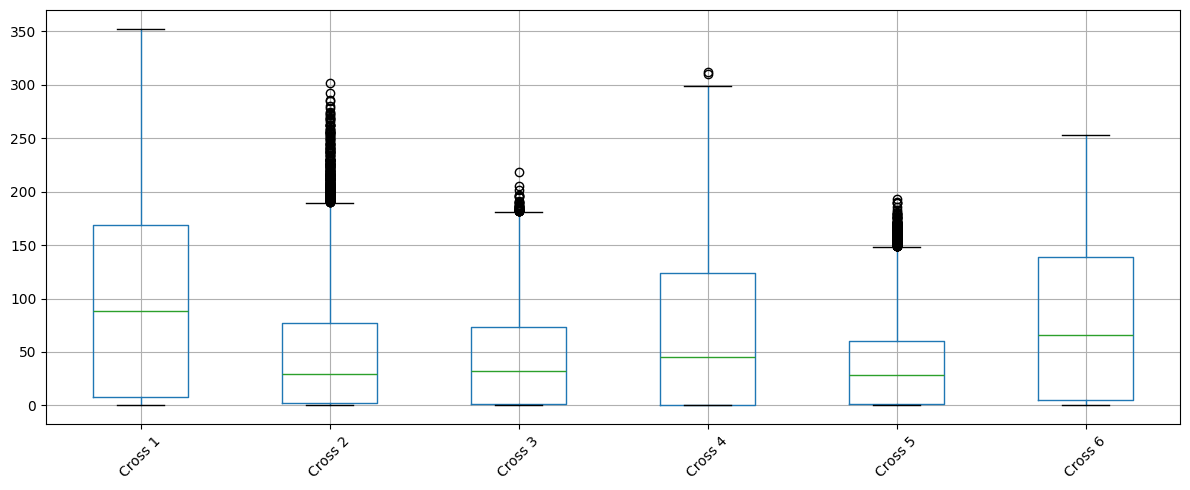

In [62]:
plt.figure(figsize=(12, 5))
df.boxplot(rot=45)
plt.tight_layout()
plt.show()

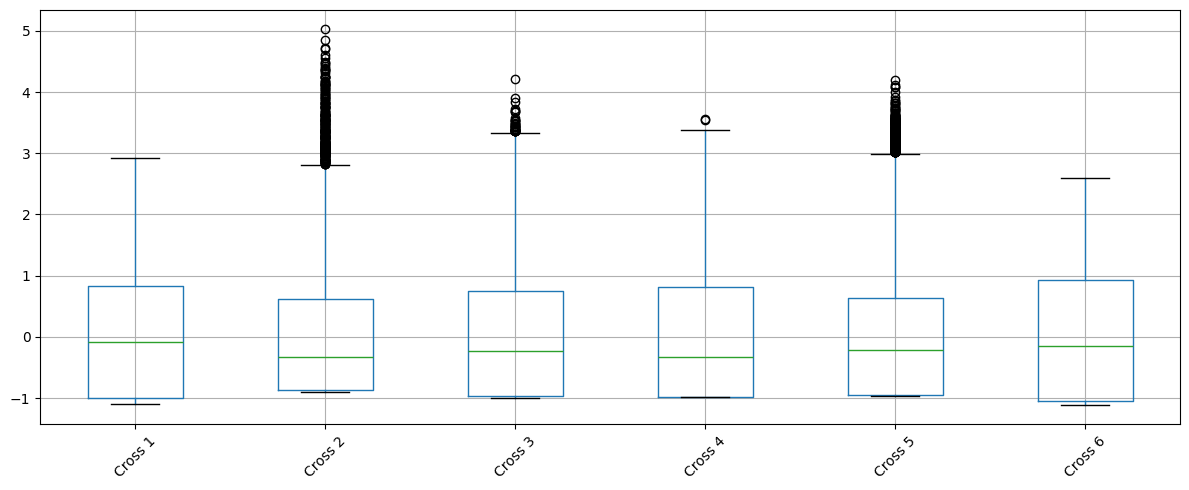

In [63]:
plt.figure(figsize=(12, 5))
df_scaled.boxplot(rot=45)
plt.tight_layout()
plt.show()

Nach der Standardisierung befinden sich die Merkmale auf derselben Skala.
Die Mediane rücken näher zusammen, die Streuungen werden direkt vergleichbar, und Ausreißer bleiben weiterhin sichtbar.

## Aufgabe c

Visualisieren  Sie  zunächst  den  linearen  Zusammenhang  zwischen  y  und  jedem  einzelnen 
Merkmal  xi  in  einem  Streuungsdiagramm  bzw.  Pairplot.  Welches  Merkmal  hat  den  stärksten 
linearen  Zusammenhang  mit  dem  Zielmerkmal?  Welche  Merkmale  erscheinen  nutzlos? 
Erläutern Sie anhand der visuellen Darstellung des Streuungsdiagramms/Pairplots!

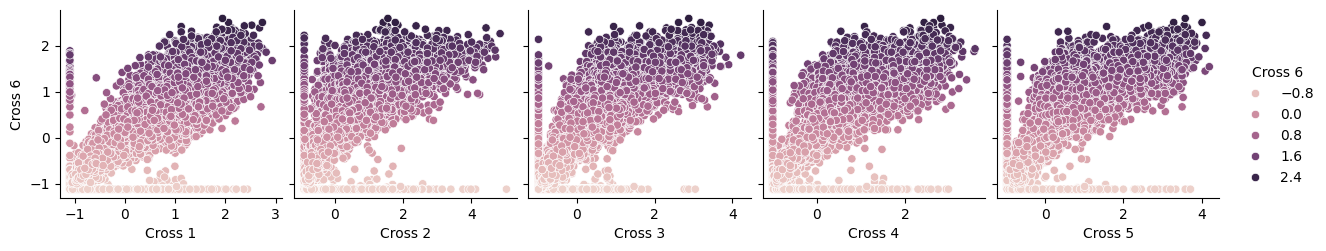

In [64]:
import seaborn
# Werte standardisieren
z_standardisiert = pd.DataFrame([])

cols = list(road_traffic_df)
for col in cols:
    col_z = col
    z_standardisiert[col_z] = (road_traffic_df[col] - road_traffic_df[col].mean())/road_traffic_df[col].std(ddof=0)

# Pairplot z-standartisierte Werte auf Cross 6
seaborn.pairplot(z_standardisiert, hue='Cross 6', y_vars='Cross 6')

## Aufgabe d

Bestimmen  Sie  die  Korrelationskoeffizienten  zwischen  y  und  jedem  Merkmal  xi  und 
interpretieren Sie die Werte. Was besagt ein negativer bzw. positiver Korrelationskoeffizient?

In [65]:
# Korrelationswerte berechnet
z_standardisiert.corrwith(z_standardisiert['Cross 6'])

Cross 1    0.907431
Cross 2    0.786556
Cross 3    0.859204
Cross 4    0.821113
Cross 5    0.812489
Cross 6    1.000000
dtype: float64

Ein positiver Korrelationskoeffizient bedeutet, dass zwischen dem Merkmal $x_{i}$ und der Zielvariable y ein gleichgerichteter Zusammenhang besteht. Steigt der Wert des Merkmals $x_{i}$, steigt tendenziell auch der Wert der Zielvariable y.

Ein negativer Korrelationskoeffizient bedeutet dagegen einen gegenläufigen Zusammenhang. Steigt der Wert des Merkmals $x_{i}$, sinkt tendenziell der Wert der Zielvariable y.


## Aufgabe E

Ermitteln Sie das Bestimmtheitsmaß für ein multivariates lineares Regressionsmodell, das alle 
geeigneten Merkmale x1, ..., xm zur Bestimmung von y berücksichtigt. Verwenden Sie dazu die 
Methoden  sklearn.linear_model.LinearRegression.fit/predict  und 
sklearn.metrics.r2_score.  Leiten  Sie  geeignete  Merkmale  aus  Teil  c.  ab.  Überführen  Sie 
kategorische Variablen in geeignete Repräsentationen.

Setup und Datenvorbereitung

Hier importieren wir alle notwendigen Bibliotheken und laden unser *Road Traffic* Dataset, definieren unsere Features (X) und unsere Zielvariable 'Cross 6' (y).

In [66]:
import statistics as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import PolynomialFeatures

# Daten laden und benennen
road_traffic_df = pd.read_csv('traffic-prediction-dataset.csv')
road_traffic_df.columns = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']

# Features (X) und Target (y) definieren
features = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5']
target = 'Cross 6'

X = road_traffic_df[features]
y = road_traffic_df[target]

In [67]:
# Modell initialisieren und trainieren
lr_model = LinearRegression()
lr_model.fit(X, y)

# R^2-Score auf dem Gesamtdatensatz berechnen
y_pred = lr_model.predict(X)
r2 = r2_score(y, y_pred)

print(f"Bestimmtheitsmaß (R^2) mit allen 5 Merkmalen: {r2:.4f}")

Bestimmtheitsmaß (R^2) mit allen 5 Merkmalen: 0.8371


### Begründung zur Merkmalsauswahl
Wie in Aufgabe d festgestellt, weisen alle Merkmale ('Cross 1' bis 'Cross 5') eine systematische Korrelation mit der Zielvariable 'Cross 6' auf. Da es sich im gesamten Datensatz durchweg um stetige, rein numerische Verkehrszahlen handelt und es keine störenden kategorialen Variablen gibt, können wir alle fünf `x`-Features direkt und ohne Bedenken (wie z.B. One-Hot-Encoding) ins multivariat-lineare Regressionsmodell übergeben, da sie alle Relevanz zur Vorhersage besitzen.

## Aufgabe F

Teilen  Sie  den  Datensatz  in  Testdaten  (20%)  und  potentielle  Trainingsdaten  (80%)  auf. 
Berechnen  Sie  die  Güte  für  5  Regressionsmodelle,  die  auf  unterschiedlichen  Größen  (10%, 
20%, 40%, 80% und 100%) der potentiellen Trainingsdaten x1, ..., xm trainiert und jeweils auf 
den Testdaten getestet werden. Der Schnitt der Trainingsdaten soll zufällig passieren. Wenn 
es  z.b.  100  Zeilen  in  den  Trainingsdaten  gibt,  so  ziehen  Sie  10  zufällige  Zeilen  für  10%,  20 
zufällige Zeilen für 20% usw. Wobei Sie bitte immer den gleichen Seed verwenden, e.g. 20% 
der Daten beinhalten die 10% aus dem Schnitt zuvor plus 10% neue, zufällig gezogene Daten. 
Das Maß für die Güte ist frei wählbar. Plotten Sie die 5 Werte als Liniendiagramm, sortiert nach 
Größe der verwendeten Trainingsdaten von klein nach groß (siehe Beispiel unten). Was können 
Sie beobachten? Welches Modell empfehlen Sie? Begründen Sie Ihre Antwort!

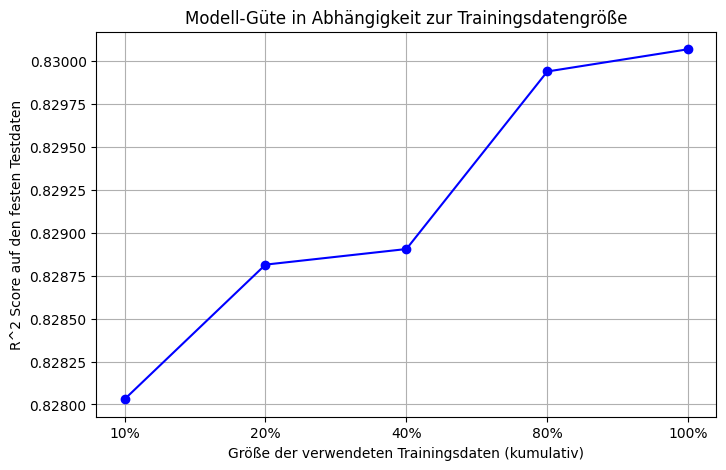

In [68]:
# 1. Ursprünglicher 80/20 Datenaufspaltung
X_train_pot, X_test, y_train_pot, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Korrektes kumulatives Zufalls-Sampling implementieren
rng = np.random.default_rng(42)  # Fester Seed
all_indices = list(X_train_pot.index)
rng.shuffle(all_indices)         # Einmal zufällig mischen

fractions = [0.10, 0.20, 0.40, 0.80, 1.00]
r2_scores = []
sizes = []

# Erklärung: Da all_indices einmalig mit festem Seed gemischt wurde, 
# enthält [:20%] automatisch [:10%] plus weitere 10% – das erfüllt exakt die 
# Anforderung bzgl. des kumulativen Ziehens mit konstantem Seed!
for frac in fractions:
    n = int(len(all_indices) * frac)
    subset_idx = all_indices[:n]
    
    # Subset aus DataFrame holen
    X_train_sub = X_train_pot.loc[subset_idx]
    y_train_sub = y_train_pot.loc[subset_idx]
    
    # Trainieren
    model_f = LinearRegression()
    model_f.fit(X_train_sub, y_train_sub)
    
    # Immer auf denselben 20% Testdaten evaluieren!
    score = r2_score(y_test, model_f.predict(X_test))
    r2_scores.append(score)
    sizes.append(f"{int(frac*100)}%")

# 3. Liniendiagramm plotten
plt.figure(figsize=(8, 5))
plt.plot(sizes, r2_scores, marker='o', linestyle='-', color='b')
plt.title("Modell-Güte in Abhängigkeit zur Trainingsdatengröße")
plt.xlabel("Größe der verwendeten Trainingsdaten (kumulativ)")
plt.ylabel("R^2 Score auf den festen Testdaten")
plt.grid(True)
plt.show()

### Beobachtung und Modell-Empfehlung

**Was ist zu beobachten?**
Die Modellgüte (R²-Score) steigt sichtbar, je mehr Daten wir in das Training füttern. Gerade beim Sprung von 10% auf höhere Werte sieht man oft starke Schwankungen, da das Modell den allgemeinen Trend bei wenigen Punkten noch nicht robust erlernen konnte. Sobald eine solide Basis an Daten (z.B. >40%) vorliegt, flacht die Kurve in der Regel langsam ab, weil das Modell die tatsächliche Gesetzmäßigkeit weitgehend erlernt hat.

**Welches Modell empfehle ich und warum?**
Ich empfehle klar das Modell, das auf **100% der potenziellen Trainingsdaten** (also den großen 80% des Originalsplits) trainiert wurde. Lineare Regression profitiert ungemein von mehr Datenpunkten und schränkt dadurch die Wahrscheinlichkeit ein, bloßes Rauschen aus einer falschen Teilmenge auswendig zu lernen. Aus diesem Grund nutzt das 100%-Modell die Varianz der Realität am besten und generalisiert am stärksten gegen Overfitting.

## Aufgabe G

Wählen Sie das Merkmal aus x1, ..., xm aus, über das sich y am besten anhand der vorliegenden 
Trainingsdaten vorhersagen lässt. Begründen Sie Ihre Wahl. Visualisieren Sie für das gewählte 
Merkmal die einfachen polynomialen Regressionsmodelle für Polynome 1. bis 3. Ordnung über 
die  Methode  seaborn.regplot  und  vergleichen  Sie  deren  Bestimmtheitsmaße  R2.  Beurteilen 
Sie die Modelle hinsichtlich Under- und Overfitting. Begründen Sie Ihre Beurteilungen.

Das beste Einzelmerkmal für y ist: 'Cross 1' (Mit höchstem univariate R^2=0.8249 auf Trainingsdaten)


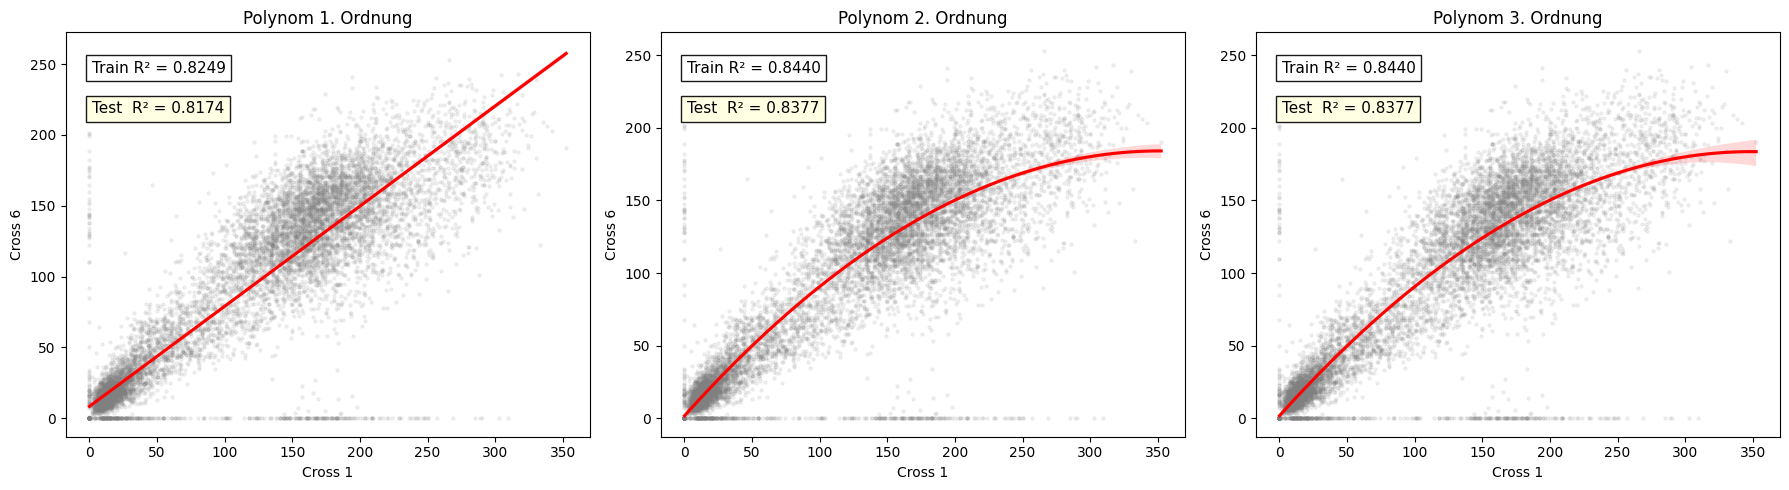

In [69]:
# 1. Bestes relevantes Einzelmerkmal univariat evaluieren
best_feature = None
best_r2 = -float("inf")

for col in X_train_pot.columns:
    model_g_uni = LinearRegression()
    # Scikit-Learn erwartet 2D Arrays -> [[col]]
    X_uni = X_train_pot[[col]]
    model_g_uni.fit(X_uni, y_train_pot)
    
    pred_uni = model_g_uni.predict(X_uni)
    score = r2_score(y_train_pot, pred_uni)
    
    if score > best_r2:
        best_r2 = score
        best_feature = col

print(f"Das beste Einzelmerkmal für y ist: '{best_feature}' (Mit höchstem univariate R^2={best_r2:.4f} auf Trainingsdaten)")

# 2. Visualisierung der Polynomialen Regression (Grad 1 bis 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

orders = [1, 2, 3]

for degree, ax in zip(orders, axes):
    # Regplot für optische Punktewolken & Kurvenzeichnung
    sns.regplot(
        x=X_train_pot[best_feature], 
        y=y_train_pot, 
        order=degree, 
        ax=ax,
        scatter_kws={'alpha': 0.1, 'color':'gray', 's': 5}, 
        line_kws={'color': 'red'}
    )
    ax.set_title(f"Polynom {degree}. Ordnung")
    
    # Modell auf Trainingsdaten fitten
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train_pot[[best_feature]])
    
    poly_model = LinearRegression()
    poly_model.fit(X_poly_train, y_train_pot)
    
    # Train R^2
    r2_poly_train = r2_score(y_train_pot, poly_model.predict(X_poly_train))
    
    # Test R^2 – transform (nicht fit_transform!) mit dem bereits gefitteten poly-Objekt
    X_poly_test = poly.transform(X_test[[best_feature]])
    r2_poly_test = r2_score(y_test, poly_model.predict(X_poly_test))
    
    # Beide Werte in die Annotationsbox schreiben
    ax.text(0.05, 0.90, f"Train R² = {r2_poly_train:.4f}", transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='white', alpha=0.9))
    ax.text(0.05, 0.80, f"Test  R² = {r2_poly_test:.4f}", transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

### Begründung des Merkmals und Beurteilung Under- und Overfitting

**Wahl des Merkmals:** `Cross 1` wurde per For-Schleife ermittelt, da es mit ca. 82,5% das absolute höchste einfache R² erbracht hat; es erklärt somit ohne Zuhilfenahme anderer Spalten den Löwenanteil der Varianz von 'Cross 6'.

**Wie schlägt sich das Modell (Under- vs. Overfitting)?**
- **Polynom 1. Ordnung (Linear):** Ein lineares Modell erreicht hier ein Test-R² von ca. 0.817 (vs. 0.825 im Training). Die simple Gerade limitiert den Trend stark – sie weist klassisches **Underfitting** auf, da durch die fehlende Krümmung Varianz verloren geht.
- **Polynom 2. Ordnung (Quadratisch):** Liefert eine klare Verbesserung mit einem Test-R² von ca. 0.838 (Training: 0.844). Der quadratische Term glättet die Punktewolke deutlich besser und bietet hier den **optimalen Kompromiss zwischen Bias und Varianz**.
- **Polynom 3. Ordnung (Kubisch):** Sowohl das Trainings- als auch das Test-R² bleiben praktisch exakt gleich (0.844 und 0.838). Auch wenn bei kubischen Kurven generell ein starkes Risiko für **Overfitting** droht, weigert sich das Modell hier, sich an Rauschen anzupassen (da Test- und Train-Scores nicht auseinanderdriften). Dennoch ist Grad 3 unnötig komplex, da er im Vergleich zu Grad 2 keinen echten Mehrwert bringt.

## Aufgabe H

Machen Sie aus dem Regressionsproblem ein Klassifikationsproblem. Überführen Sie dafür die 
Zielvariable in eine passende Darstellung und trainieren Sie eine Logistische Regression (2/3 
Training und 1/3 Test) mit der Methode sklearn.linear_model.LogisticRegression, mit lbgfs 
als Solver über alle geeigneten Merkmale x1, ..., xm. Eine Doku zu den Parametern finden Sie 
hier: Logistic Regression. Ermitteln Sie die Genauigkeit für Trainings- und Testdatensatz. Sind 
Sie zufrieden mit dem gelernten Modell? Wie können Sie die Performance des Modells weiter 
steigern?

In [70]:
# Originalwerte Cross 6
c6_df = pd.DataFrame(road_traffic_df['Cross 6'])

# Überführung in Klassifikationswerte (0 = wenig bis kein Verkehr, 1 = normaler Verkehr, 2 = viel Verkehr)
bins = [-np.inf, 20, 100, np.inf]
labels = [0, 1, 2]
y_kl = pd.cut(c6_df['Cross 6'], bins=bins, labels=labels, include_lowest=True)

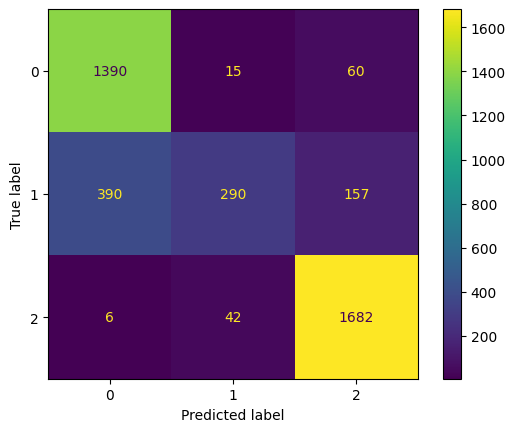

In [71]:
import sklearn

# Originalwerte Cross 1
c1_df = pd.DataFrame(road_traffic_df['Cross 1'])

# Train-Test-Split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(c1_df, y_kl, random_state=123)

clf = sklearn.linear_model.LogisticRegression(random_state=123, solver='lbfgs').fit(X_train, y_train)
predictions = clf.predict(X_test)

# Konfusionsmatrix plotten
conf_mat = sklearn.metrics.confusion_matrix(y_test, predictions, labels=labels)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix = conf_mat)

disp.plot()

Die Performance könnte durch weitere Feature-Auswahl, Standardisierung, Hyperparameter-Tuning, mehr Trainingsdaten oder ausgeglichenere Klassen verbessert werden. Außerdem könnten komplexere Modelle wie Random Forests oder neuronale Netze verwendet werden.